In [2]:
# We are doing Prompt Chaining here - START  --> gen_outline --> gen_blog --> evaluate -->  END

In [3]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict
from dotenv import load_dotenv

In [4]:
import os
load_dotenv()

True

In [5]:
model = ChatOpenAI()

In [6]:
# Create a state

class BlogState(TypedDict):
    
    title: str
    outline:str
    content: str
    evaluate: str

In [7]:
def create_outline(state: BlogState) -> BlogState:
    
    # Extract the title from the state
    title = state['title']
    
    
    # form a prompt
    prompt = f"Create a detailed outline for a blog on the topic of: {title}"
    
    # ask that question to the LLM
    outline_answer = str(model.invoke(prompt).content)
    
    
    # update the state with the answer and return it
    state['outline'] = outline_answer
    
    return state

In [8]:
def create_blog(state: BlogState) -> BlogState:
    
    # Extract the title and outline from the state
    title = state['title']
    outline = state['outline']
    
    
    # form a prompt
    prompt = f"Create a detailed blog post with the title: {title} and the following outline: {outline}"
    
    # ask that question to the LLM
    content_answer = str(model.invoke(prompt).content)
    
    
    # update the state with the answer and return it
    state['content'] = content_answer
    
    return state

In [19]:
def evaluate_blog(state: BlogState) -> BlogState:
    
    # Extract the title and content from the state
    title = state['title']
    content = state['content']
    
    
    # form a prompt
    prompt = f"Evaluate my blog post in detail with the given title: {title} and content: {content} and give a score out of 5 along with detailed feedback on how I can improve it."
    
    # ask that question to the LLM
    content_answer = str(model.invoke(prompt).content)
    
    
    # update the state with the answer and return it
    state['evaluate'] = content_answer
    
    return state

In [20]:
# Create our graph

graph = StateGraph(BlogState)


# add nodes to your graph
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)
graph.add_node('evaluate_blog', evaluate_blog)


# add edges to your graph
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', 'evaluate_blog')
graph.add_edge('evaluate_blog', END)

# compile your graph 
llm_qa_workflow = graph.compile()

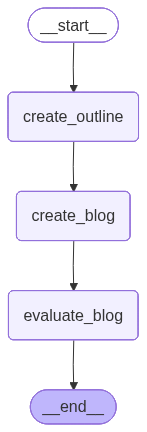

In [21]:
from IPython.display import Image
Image(llm_qa_workflow.get_graph().draw_mermaid_png())

In [22]:
# execute your graph

initial_state: BlogState = {'title': 'Rise of AI in India', 'outline': '', 'content': '', 'evaluate': ''}

final_state = llm_qa_workflow.invoke(initial_state)

print(final_state)

{'title': 'Rise of AI in India', 'outline': 'I. Introduction\n    A. Definition of AI (Artificial Intelligence) \n    B. Brief overview of the rise of AI globally \n    C. Introduction to the current scenario of AI in India \n\nII. History of AI in India \n    A. Evolution of AI technology in India \n    B. Key milestones in the development of AI in India \n    C. Overview of AI research and innovation in India \n\nIII. Current landscape of AI in India \n    A. Key industries adopting AI technology in India\n        1. Healthcare \n        2. Finance \n        3. Retail \n        4. Agriculture \n    B. Government initiatives to promote AI adoption in India \n    C. Challenges and barriers to AI implementation in India \n\nIV. Impact of AI on the Indian economy \n    A. Economic benefits of AI adoption in India \n    B. Job market implications of AI in India \n    C. Potential for AI to drive economic growth and innovation in India \n\nV. Future of AI in India \n    A. Predictions for 

In [23]:
print("Title: ", final_state['title'])

Title:  Rise of AI in India


In [24]:
print("Outline: ", final_state['outline'])

Outline:  I. Introduction
    A. Definition of AI (Artificial Intelligence) 
    B. Brief overview of the rise of AI globally 
    C. Introduction to the current scenario of AI in India 

II. History of AI in India 
    A. Evolution of AI technology in India 
    B. Key milestones in the development of AI in India 
    C. Overview of AI research and innovation in India 

III. Current landscape of AI in India 
    A. Key industries adopting AI technology in India
        1. Healthcare 
        2. Finance 
        3. Retail 
        4. Agriculture 
    B. Government initiatives to promote AI adoption in India 
    C. Challenges and barriers to AI implementation in India 

IV. Impact of AI on the Indian economy 
    A. Economic benefits of AI adoption in India 
    B. Job market implications of AI in India 
    C. Potential for AI to drive economic growth and innovation in India 

V. Future of AI in India 
    A. Predictions for the future of AI technology in India 
    B. Opportunities f

In [25]:
print("Blog Content: ", final_state['content'])

Blog Content:  The Rise of AI in India

I. Introduction 
A. Definition of AI (Artificial Intelligence) 
Artificial Intelligence, commonly known as AI, refers to the simulation of human intelligence in machines that are programmed to think and act like humans. These machines are designed to perform tasks such as learning, reasoning, problem-solving, perception, and speech recognition. 
B. Brief overview of the rise of AI globally 
In recent years, AI has seen a rapid rise in adoption and development globally. Countries around the world are investing heavily in AI research and innovation to stay competitive in the digital age. 
C. Introduction to the current scenario of AI in India 
India, known for its vast population and rapidly growing economy, has also been catching up with the global trend of AI adoption. With a growing tech-savvy workforce and government support for digital initiatives, India has become a key player in the development and deployment of AI technology.

II. History o

In [26]:
print("Evaluate: ", final_state['evaluate'])

Evaluate:  Overall, this blog post provides a thorough overview of the rise of AI in India, covering key aspects such as the history of AI in India, the current landscape of AI technology adoption, the impact of AI on the Indian economy, and the future of AI in India. The content is well-structured, informative, and provides insights into the potential opportunities and challenges associated with AI technology in India.

To improve the blog post, consider incorporating more specific examples of AI implementation in India across different industries. This will help to provide a clearer picture of how AI is being utilized in real-world scenarios in the country. Additionally, you could include more statistics or data to support your claims about the economic benefits and job market implications of AI adoption in India.

In terms of the writing style, consider varying your sentence structure and using more engaging language to keep readers interested throughout the blog post. Adding visual